This notebook reproduces **DeepLOB** (Zhang, Zohren & Roberts, IEEE TSP 2019), a CNN+LSTM that predicts short-horizon mid-price moves directly from the raw 10-level limit order book, and extends it with a **Dirichlet / evidential** head so the network can report calibrated uncertainty alongside its predictions, letting us act only when it is confident.

**Why DeepLOB.** At HFT timescales the signal lives in the interaction of bid build-ups, ask erosions, deep-queue dynamics, and short bursts of aggression across many levels and many ticks. The authors stopped trying to hand-engineer features for that and fed the raw 40-column tick snapshot (10 bid + 10 ask levels × price and volume) straight into a conv stack: a `(1,2)` conv couples price and volume per level, deeper `(4,1)` convs capture short tick patterns, a `(1,10)` collapses across levels, an Inception block sees multiple temporal scales, and an LSTM stitches the 82-step sequence into one prediction. On FI-2010 this reaches the low-70s in test accuracy on a 3-class up/flat/down task, clean separation from any feature-engineering baseline.

**Why we modify the head.** Softmax always returns three probabilities that sum to one, it cannot say "I don't know." On most ticks the next mid-price move is dominated by microstructure noise, but softmax still picks a class with conviction. Trading every prediction means high turnover, many losing bets on noisy windows, and the genuinely informative predictions diluted away.

**The fix:** 

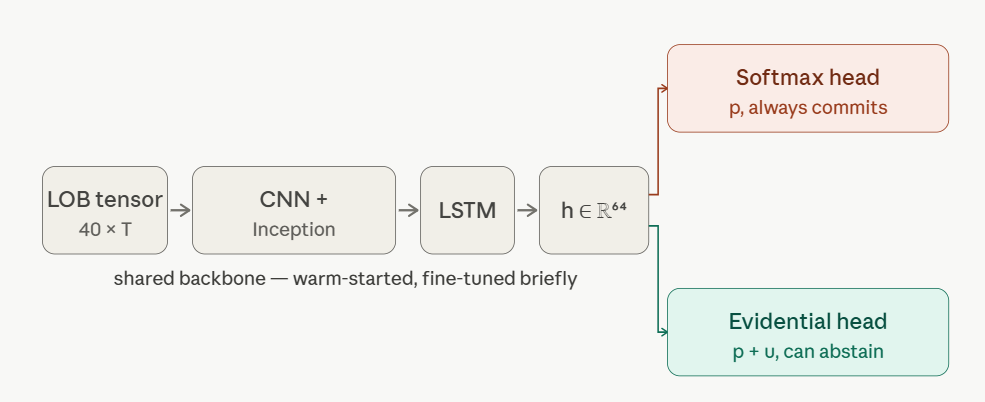

Replace softmax with a Dirichlet head (Sensoy et al., NeurIPS 2018). The network outputs three non-negative *evidences* via `softplus`; we form α = e + 1, S = Σ α_k, predicted probability p = α / S, and a scalar uncertainty u = K / S ∈ (0, 1]. When the network has no evidence to offer, u → 1 and we stay flat. The loss is expected-MSE on p plus a KL term penalising evidence on wrong classes, annealed 0 → 1 over the first ten epochs to avoid early collapse to the uniform prior. The conv stack, Inception, and LSTM stay byte-identical, so we warm-start from the trained softmax checkpoint and fine-tune only briefly.

**Selective prediction rule.** Output `argmax p_k` only when `max p_k > β` **and** `u < τ`; otherwise abstain. Pick `(β, τ)` on the validation set, never on test. The rest of the notebook trains the baseline DeepLOB, evaluates it, fine-tunes the evidential head, then compares the two head-to-head and asks whether the uncertainty signal is real.

---

## Result

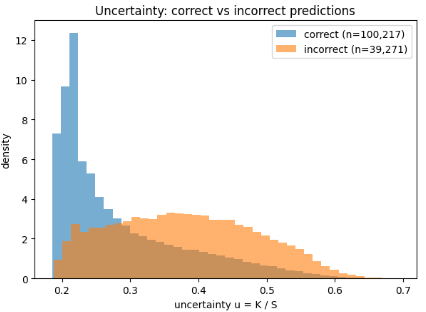

**Overall metrics on the held-out test set (139,488 windows):**

| Model | Coverage | n kept | Accuracy | Macro Prec | Macro Rec | Macro F1 |
|---|---:|---:|---:|---:|---:|---:|
| Softmax (baseline) | 100% | 139,488 | 0.7216 | 0.7224 | 0.7209 | 0.7213 |
| Evidential (no filter) | 100% | 139,488 | 0.7185 | 0.7212 | 0.7189 | 0.7187 |
| **Evidential filtered** (β = 0.82, τ = 0.25) | **40.0%** | 55,764 | **0.9137** | **0.9130** | **0.9126** | **0.9127** |

**Per-class precision** (0 = down, 1 = stable, 2 = up):

| Model | Down | Stable | Up |
|---|---:|---:|---:|
| Softmax (baseline) | 0.6892 | 0.7857 | 0.6923 |
| Evidential (no filter) | 0.7107 | 0.7977 | 0.6551 |
| **Evidential filtered** | **0.9146** | **0.9279** | **0.8964** |

### Conclusion

Without filtering, evidential and softmax are essentially tied (~72% accuracy). The head swap on its own is not the win, the two parameterisations are roughly equivalent classifiers. What matters is the *signal* the Dirichlet head produces alongside the prediction.

Once the selective rule is applied, accuracy jumps from ~72% to **~91%** on the kept 40% of samples, and every macro metric moves in lockstep. The biggest improvements are on the **directional classes (down and up)**: precision climbs from ~0.69 to ~0.91, exactly where trading edge lives. The "stable" class also improves (0.79 → 0.93) but in relative terms it gained the least, since it was already the easiest class to call correctly. Most of the lift comes from the model confidently refusing the noisy windows where it would have mis-called up or down.

In [2]:
import os
from pathlib import Path

required_files = [
    'Train_Dst_NoAuction_DecPre_CF_7.txt',
    'Test_Dst_NoAuction_DecPre_CF_7.txt',
    'Test_Dst_NoAuction_DecPre_CF_8.txt',
    'Test_Dst_NoAuction_DecPre_CF_9.txt',
]

if not all(Path(name).is_file() for name in required_files):
    if not Path('data.zip').is_file():
        !wget https://raw.githubusercontent.com/zcakhaa/DeepLOB-Deep-Convolutional-Neural-Networks-for-Limit-Order-Books/master/data/data.zip
    !unzip -n data.zip
    print('data downloaded.')
else:
    print('data already exists.')


data already exists.


In [3]:
import os
import resource
from contextlib import nullcontext
from datetime import datetime
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from torchinfo import summary
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils import data

from deeplob_data import (
    CachedArrayView,
    ConcatenatedCachedArrayView,
    SlidingWindowDataset,
    ensure_cached_dataset,
    open_memmap,
    recommended_num_workers,
    split_train_validation,
)


/home/trn/miniconda3/envs/deeplob/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
amp_enabled = device.type == 'cuda'
default_batch_size = 256 if amp_enabled else 32
batch_size = default_batch_size
num_workers = 0
pin_memory = False
persistent_workers = num_workers > 0
prefetch_factor = 2 if num_workers > 0 else None
epochs = 50
max_train_batches = None
max_eval_batches = None
cache_dir = Path('.cache/deeplob')
ram_limit_gb = 20.0
gpu_limit_gb = 16.0
checkpoint_dir = Path('./checkpoints')
best_model_path = checkpoint_dir / 'best_val_model_pytorch.pt'
latest_model_path = checkpoint_dir / 'latest_model_pytorch.pt'
save_every_epochs = 1
early_stopping_patience = 8
early_stopping_min_delta = 1e-4

if device.type == 'cuda' and gpu_limit_gb > 0:
    total_gpu_bytes = torch.cuda.get_device_properties(device).total_memory
    requested_gpu_bytes = int(gpu_limit_gb * (1024 ** 3))
    fraction = min(0.98, max(0.0, requested_gpu_bytes / total_gpu_bytes))
    if fraction <= 0:
        raise ValueError('gpu_limit_gb must be > 0 when set')
    torch.cuda.set_per_process_memory_fraction(fraction, device=device)

print({
    'device': str(device),
    'batch_size': batch_size,
    'num_workers': num_workers,
    'pin_memory': pin_memory,
    'epochs': epochs,
    'cache_dir': str(cache_dir),
    'ram_limit_gb': ram_limit_gb,
    'gpu_limit_gb': gpu_limit_gb,
    'checkpoint_dir': str(checkpoint_dir),
    'save_every_epochs': save_every_epochs,
    'early_stopping_patience': early_stopping_patience,
    'early_stopping_min_delta': early_stopping_min_delta,
})


{'device': 'cuda:0', 'batch_size': 256, 'num_workers': 0, 'pin_memory': False, 'epochs': 50, 'cache_dir': '.cache/deeplob', 'ram_limit_gb': 20.0, 'gpu_limit_gb': 16.0, 'checkpoint_dir': 'checkpoints', 'save_every_epochs': 1, 'early_stopping_patience': 8, 'early_stopping_min_delta': 0.0001}


In [5]:
def _current_rss_mb():
    with open('/proc/self/status', 'r', encoding='utf-8') as handle:
        for line in handle:
            if line.startswith('VmRSS:'):
                parts = line.split()
                return float(parts[1]) / 1024.0
    return 0.0


def report_runtime(label):
    rss_mb = _current_rss_mb()
    if ram_limit_gb > 0 and rss_mb > ram_limit_gb * 1024:
        raise MemoryError(
            f'RAM limit exceeded at {label}: {rss_mb:.1f} MB > {ram_limit_gb * 1024:.1f} MB'
        )

    if device.type == 'cuda':
        allocated_mb = torch.cuda.memory_allocated(device) / (1024 ** 2)
        reserved_mb = torch.cuda.memory_reserved(device) / (1024 ** 2)
        print(f'{label} | RAM rss={rss_mb:.1f} MB | GPU allocated={allocated_mb:.1f} MB | GPU reserved={reserved_mb:.1f} MB')
    else:
        print(f'{label} | RAM rss={rss_mb:.1f} MB')


def build_loader(dataset, shuffle):
    kwargs = {
        'dataset': dataset,
        'batch_size': batch_size,
        'shuffle': shuffle,
        'num_workers': num_workers,
        'pin_memory': pin_memory,
    }
    if num_workers > 0:
        kwargs['persistent_workers'] = persistent_workers
        kwargs['prefetch_factor'] = prefetch_factor
    return torch.utils.data.DataLoader(**kwargs)


In [6]:
def get_autocast_context():
    if not amp_enabled:
        return nullcontext()
    return torch.autocast(device_type='cuda', dtype=torch.float16)


if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
    scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)
else:
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


## The data

FI-2010 is the standard benchmark for this kind of work: five Nordic stocks across ten trading days, each tick captured as the top ten bid and ten ask levels of `(price, volume)`, forty numbers per tick. The "no-auction, decimal-precision" variant we use strips the opening and closing auctions and rescales so absolute magnitudes don't leak between stocks.

We follow the paper's split, first seven days for training (with 20% held out as validation), last three days as the test set, and use the 50-tick mid-price-move horizon (`k = 4`) with three classes: up, stable, down. Inputs are sliding windows of `T = 100` consecutive ticks.

In [7]:
train_cache = ensure_cached_dataset('Train_Dst_NoAuction_DecPre_CF_7.txt', cache_dir)
train_array = open_memmap(train_cache.cache_path)
train_view, val_view = split_train_validation(train_array, train_fraction=0.8)

test_views = []
for test_name in [
    'Test_Dst_NoAuction_DecPre_CF_7.txt',
    'Test_Dst_NoAuction_DecPre_CF_8.txt',
    'Test_Dst_NoAuction_DecPre_CF_9.txt',
]:
    cache_info = ensure_cached_dataset(test_name, cache_dir)
    test_views.append(CachedArrayView(open_memmap(cache_info.cache_path)))

test_view = ConcatenatedCachedArrayView(test_views)
print(train_view.shape, val_view.shape, test_view.shape)
report_runtime('After cache open')


(149, 203800) (149, 50950) (149, 139587)
After cache open | RAM rss=671.5 MB | GPU allocated=0.0 MB | GPU reserved=0.0 MB


In [8]:
dataset_train = SlidingWindowDataset(view=train_view, k=4, num_classes=3, T=100)
dataset_val = SlidingWindowDataset(view=val_view, k=4, num_classes=3, T=100)
dataset_test = SlidingWindowDataset(view=test_view, k=4, num_classes=3, T=100)

train_loader = build_loader(dataset_train, shuffle=True)
val_loader = build_loader(dataset_val, shuffle=False)
test_loader = build_loader(dataset_test, shuffle=False)

print({
    'train_samples': len(dataset_train),
    'val_samples': len(dataset_val),
    'test_samples': len(dataset_test),
})
report_runtime('After dataloader setup')


{'train_samples': 203701, 'val_samples': 50851, 'test_samples': 139488}
After dataloader setup | RAM rss=671.5 MB | GPU allocated=0.0 MB | GPU reserved=0.0 MB


In [9]:
for x, y in train_loader:
    print(x.shape, y.shape, x.dtype, y.dtype)
    break


torch.Size([256, 1, 100, 40]) torch.Size([256]) torch.float32 torch.int64


## The model

Below is the original DeepLOB architecture. Reading it as a forward pass tells you what the network "sees": the first block pairs up price-and-volume at each level, the next two squeeze across levels and across short tick windows, the Inception head looks at the resulting 82-step sequence at multiple temporal scales, and the LSTM rolls everything into one classification. We keep this intact; the evidential variant later reuses every layer below the final linear.

In [10]:
class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
#             nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception moduels
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        # h0: (number of hidden layers, batch size, hidden size)
        h0 = torch.zeros(1, x.size(0), 64).to(device)
        c0 = torch.zeros(1, x.size(0), 64).to(device)
    
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)  
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        
#         x = torch.transpose(x, 1, 2)
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))
        
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        forecast_y = torch.softmax(x, dim=1)
        
        return forecast_y

In [11]:
model = deeplob(y_len=dataset_train.num_classes)
model.to(device)
report_runtime('After model init')


After model init | RAM rss=844.6 MB | GPU allocated=0.6 MB | GPU reserved=2.0 MB


In [12]:
summary(model, (1, 1, 100, 40), device=str(device))


Layer (type:depth-idx)                   Output Shape              Param #
deeplob                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 32, 94, 20]           --
│    └─Conv2d: 2-1                       [1, 32, 100, 20]          96
│    └─LeakyReLU: 2-2                    [1, 32, 100, 20]          --
│    └─BatchNorm2d: 2-3                  [1, 32, 100, 20]          64
│    └─Conv2d: 2-4                       [1, 32, 97, 20]           4,128
│    └─LeakyReLU: 2-5                    [1, 32, 97, 20]           --
│    └─BatchNorm2d: 2-6                  [1, 32, 97, 20]           64
│    └─Conv2d: 2-7                       [1, 32, 94, 20]           4,128
│    └─LeakyReLU: 2-8                    [1, 32, 94, 20]           --
│    └─BatchNorm2d: 2-9                  [1, 32, 94, 20]           64
├─Sequential: 1-2                        [1, 32, 88, 10]           --
│    └─Conv2d: 2-10                      [1, 32, 94, 10]           2,080
│    └

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


## Training the baseline

Nothing exotic: cross-entropy, Adam at 1e-4, AMP on CUDA, early-stopping on validation loss. The goal here is a solid softmax checkpoint to compare against, and to warm-start the evidential fine-tune from.

In [14]:
def batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs):
    train_losses = np.full(epochs, np.nan, dtype=np.float64)
    test_losses = np.full(epochs, np.nan, dtype=np.float64)
    best_test_loss = np.inf
    best_test_epoch = 0
    no_improve_epochs = 0

    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for it in tqdm(range(epochs)):
        model.train()
        t0 = datetime.now()
        train_loss = []

        for batch_idx, (inputs, targets) in enumerate(train_loader):
            if max_train_batches is not None and batch_idx >= max_train_batches:
                break

            inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)
            targets = targets.to(device, dtype=torch.int64, non_blocking=pin_memory)
            optimizer.zero_grad(set_to_none=True)

            with get_autocast_context():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss.append(loss.item())

        train_loss = float(np.mean(train_loss)) if train_loss else np.nan

        model.eval()
        test_loss = []
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(test_loader):
                if max_eval_batches is not None and batch_idx >= max_eval_batches:
                    break

                inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)
                targets = targets.to(device, dtype=torch.int64, non_blocking=pin_memory)
                with get_autocast_context():
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                test_loss.append(loss.item())

        test_loss = float(np.mean(test_loss)) if test_loss else np.nan
        train_losses[it] = train_loss
        test_losses[it] = test_loss

        checkpoint_payload = {
            'epoch': it + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'train_loss': train_loss,
            'val_loss': test_loss,
            'best_val_loss': best_test_loss,
            'no_improve_epochs': no_improve_epochs,
        }
        torch.save(checkpoint_payload, latest_model_path)

        if save_every_epochs > 0 and (it + 1) % save_every_epochs == 0:
            epoch_checkpoint_path = checkpoint_dir / f'epoch_{it+1:03d}.pt'
            torch.save(checkpoint_payload, epoch_checkpoint_path)

        improved = test_loss < (best_test_loss - early_stopping_min_delta)
        if improved:
            torch.save(model.state_dict(), best_model_path)
            best_test_loss = test_loss
            best_test_epoch = it
            no_improve_epochs = 0
            print('best model saved')
        else:
            no_improve_epochs += 1

        dt = datetime.now() - t0
        print(
            f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, '
            f'Validation Loss: {test_loss:.4f}, Duration: {dt}, Best Val Epoch: {best_test_epoch}, '
            f'No-Improve: {no_improve_epochs}/{early_stopping_patience}'
        )
        report_runtime(f'Epoch {it+1}')

        if early_stopping_patience is not None and no_improve_epochs >= early_stopping_patience:
            print(f'Early stopping at epoch {it+1} (patience={early_stopping_patience}, min_delta={early_stopping_min_delta}).')
            last_idx = it + 1
            return train_losses[:last_idx], test_losses[:last_idx]

    return train_losses, test_losses


In [16]:
train_losses, val_losses = batch_gd(
    model,
    criterion,
    optimizer,
    train_loader,
    val_loader,
    epochs=epochs,
)


  2%|▏         | 1/50 [00:14<12:04, 14.78s/it]

best model saved
Epoch 1/50, Train Loss: 1.0124, Validation Loss: 1.0931, Duration: 0:00:14.784040, Best Val Epoch: 0, No-Improve: 0/8
Epoch 1 | RAM rss=2061.5 MB | GPU allocated=25.9 MB | GPU reserved=634.0 MB


  4%|▍         | 2/50 [00:29<11:50, 14.81s/it]

best model saved
Epoch 2/50, Train Loss: 0.9613, Validation Loss: 1.0681, Duration: 0:00:14.829583, Best Val Epoch: 1, No-Improve: 0/8
Epoch 2 | RAM rss=2062.3 MB | GPU allocated=25.9 MB | GPU reserved=634.0 MB


  6%|▌         | 3/50 [00:44<11:33, 14.75s/it]

...

Epoch 37/50, Train Loss: 0.6930, Validation Loss: 0.9319, Duration: 0:00:15.180162, Best Val Epoch: 30, No-Improve: 6/8
Epoch 37 | RAM rss=2064.9 MB | GPU allocated=25.9 MB | GPU reserved=634.0 MB


 76%|███████▌  | 38/50 [09:29<03:02, 15.24s/it]

Epoch 38/50, Train Loss: 0.6911, Validation Loss: 0.9108, Duration: 0:00:15.156624, Best Val Epoch: 30, No-Improve: 7/8
Epoch 38 | RAM rss=2064.6 MB | GPU allocated=25.9 MB | GPU reserved=634.0 MB


 76%|███████▌  | 38/50 [09:44<03:04, 15.39s/it]

Epoch 39/50, Train Loss: 0.6891, Validation Loss: 0.9130, Duration: 0:00:15.212863, Best Val Epoch: 30, No-Improve: 8/8
Epoch 39 | RAM rss=2064.8 MB | GPU allocated=25.9 MB | GPU reserved=634.0 MB
Early stopping at epoch 39 (patience=8, min_delta=0.0001).


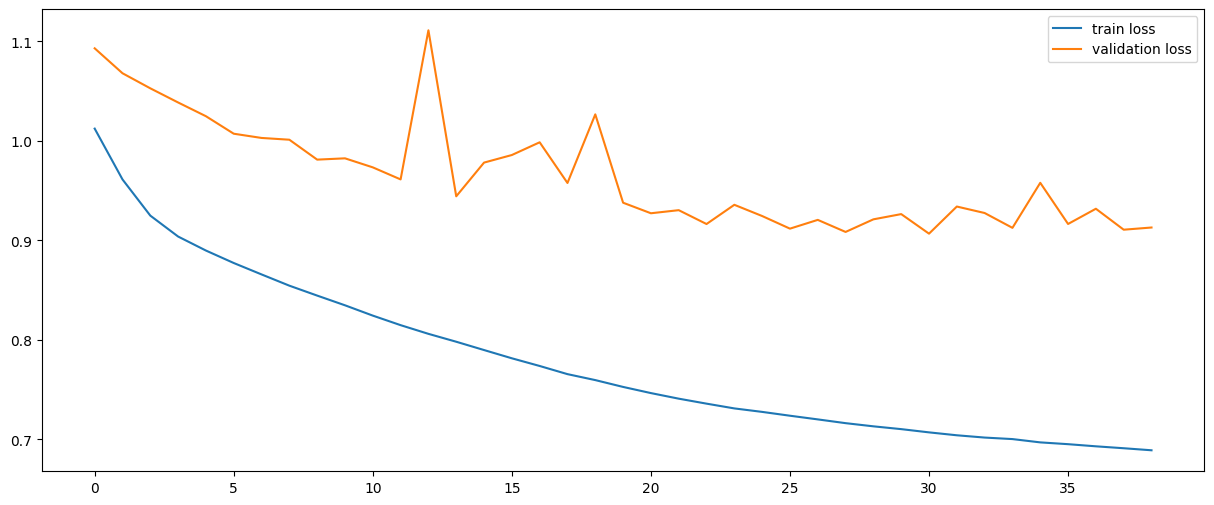

In [17]:
plt.figure(figsize=(15,6))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='validation loss')
plt.legend()

## Evaluating the baseline

We score the softmax model on the three held-out test days and also measure inference latency, since any HFT-style use of this network has to be fast. The accuracy, per-class precision and inference speed we get here become the bar the evidential variant has to clear.

In [18]:
def benchmark_inference(model, loader, warmup_batches=10, measure_batches=100):
    model.eval()
    timed_batches = 0
    timed_samples = 0
    total_seconds = 0.0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(loader):
            if max_eval_batches is not None and batch_idx >= max_eval_batches:
                break

            inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)

            if batch_idx < warmup_batches:
                with get_autocast_context():
                    _ = model(inputs)
                continue

            if timed_batches >= measure_batches:
                break

            if device.type == 'cuda':
                torch.cuda.synchronize(device)
            t0 = time.perf_counter()
            with get_autocast_context():
                _ = model(inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize(device)

            total_seconds += time.perf_counter() - t0
            timed_batches += 1
            timed_samples += inputs.shape[0]

    if timed_batches == 0:
        raise RuntimeError('No batches measured. Increase test data or reduce warmup_batches.')

    return {
        'timed_batches': timed_batches,
        'timed_samples': timed_samples,
        'total_seconds': total_seconds,
        'batches_per_second': timed_batches / total_seconds,
        'samples_per_second': timed_samples / total_seconds,
        'ms_per_batch': (total_seconds / timed_batches) * 1000.0,
        'ms_per_sample': (total_seconds / timed_samples) * 1000.0,
    }


model = deeplob(y_len=dataset_train.num_classes).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

n_correct = 0.0
n_total = 0.0
with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(test_loader):
        if max_eval_batches is not None and batch_idx >= max_eval_batches:
            break

        inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)
        targets = targets.to(device, dtype=torch.int64, non_blocking=pin_memory)
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        n_correct += (predictions == targets).sum().item()
        n_total += targets.shape[0]

test_acc = n_correct / n_total
print(f'Test acc: {test_acc:.4f}')

speed_stats = benchmark_inference(model, test_loader, warmup_batches=10, measure_batches=100)
print('inference_speed:', speed_stats)


Test acc: 0.7215
inference_speed: {'timed_batches': 100, 'timed_samples': 25600, 'total_seconds': 0.2542917528189719, 'batches_per_second': 393.24908846410426, 'samples_per_second': 100671.76664681069, 'ms_per_batch': 2.5429175281897187, 'ms_per_sample': 0.009933271594491089}


In [19]:
all_targets = []
all_predictions = []

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(test_loader):
        if max_eval_batches is not None and batch_idx >= max_eval_batches:
            break

        inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)
        targets = targets.to(device, dtype=torch.int64, non_blocking=pin_memory)
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        all_targets.append(targets.cpu().numpy())
        all_predictions.append(predictions.cpu().numpy())

all_targets = np.concatenate(all_targets)
all_predictions = np.concatenate(all_predictions)


In [20]:
print('accuracy_score:', accuracy_score(all_targets, all_predictions))
print(classification_report(all_targets, all_predictions, digits=4))

accuracy_score: 0.7215100940582703
              precision    recall  f1-score   support

           0     0.6898    0.7193    0.7043     47915
           1     0.7866    0.7431    0.7642     48050
           2     0.6905    0.7002    0.6953     43523

    accuracy                         0.7215    139488
   macro avg     0.7223    0.7208    0.7212    139488
weighted avg     0.7233    0.7215    0.7221    139488



## Adding the evidential head

Now the modification. Everything from `conv1` through the LSTM stays exactly as before; only the very last activation changes. Instead of squashing the logits with `softmax`, we push them through `softplus` and treat the three non-negative outputs as *evidences* `e`. The Dirichlet parameters are then `α = e + 1`, the predicted class probabilities are `p = α / S`, and we get a scalar uncertainty `u = K / S` that lives in `(0, 1]`. The number on the right of that interval is where the model is admitting it has no evidence to offer; the number on the left is where it has so much that the prediction is sharp.

The training loss is no longer cross-entropy. Following Sensoy 2018 we use the expected mean-squared error on `p`, which has a natural variance term that pushes the network to allocate evidence carefully, plus a KL regulariser that punishes evidence assigned to the *wrong* classes. To stop that KL term from collapsing the Dirichlet to uniform in the very first batches, its weight is annealed linearly from 0 to 1 over the first ten epochs.

We load the trained softmax checkpoint as a warm start. Because the backbone weights barely need to move (only the head's *role* changes), fifteen epochs at the same learning rate are enough.

In [22]:
import math
import torch.nn.functional as F


class deeplob_evidential(nn.Module):
    """DeepLOB with a Dirichlet/evidential head instead of softmax.

    Forward returns the *evidences* (non-negative). Helpers compute α, p, u.
    """

    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        # Same backbone as the original DeepLOB
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, (1, 2), stride=(1, 2)), nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)), nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)), nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, (1, 2), stride=(1, 2)), nn.Tanh(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)), nn.Tanh(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)), nn.Tanh(), nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, (1, 10)), nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)), nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, (4, 1)), nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        self.inp1 = nn.Sequential(
            nn.Conv2d(32, 64, (1, 1), padding='same'), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, (3, 1), padding='same'), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(32, 64, (1, 1), padding='same'), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, (5, 1), padding='same'), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(32, 64, (1, 1), padding='same'), nn.LeakyReLU(0.01), nn.BatchNorm2d(64),
        )
        self.lstm = nn.LSTM(192, 64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, y_len)

    def forward(self, x):
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        x = torch.cat((self.inp1(x), self.inp2(x), self.inp3(x)), dim=1)
        x = x.permute(0, 2, 1, 3).reshape(-1, x.shape[2], x.shape[1])
        x, _ = self.lstm(x)
        logits = self.fc1(x[:, -1, :])
        evidence = F.softplus(logits)  # non-negative evidences
        return evidence


def evidential_outputs(evidence):
    """Given evidences [B, K], return (alpha, S, p, u)."""
    alpha = evidence + 1.0
    S = alpha.sum(dim=1, keepdim=True)
    p = alpha / S
    K = evidence.shape[1]
    u = K / S.squeeze(1)
    return alpha, S.squeeze(1), p, u


def kl_dirichlet_uniform(alpha):
    """KL(D(alpha) || D(1, ..., 1)) for each row."""
    K = alpha.shape[1]
    S = alpha.sum(dim=1, keepdim=True)
    # log Gamma(S) - log Gamma(K) - sum log Gamma(alpha_k)
    #   + sum (alpha_k - 1) * (digamma(alpha_k) - digamma(S))
    term1 = torch.lgamma(S.squeeze(1)) - math.lgamma(K) - torch.lgamma(alpha).sum(dim=1)
    term2 = ((alpha - 1.0) * (torch.digamma(alpha) - torch.digamma(S))).sum(dim=1)
    return term1 + term2


def evidential_mse_loss(evidence, target_onehot, kl_weight):
    """Sensoy 2018 expected-MSE loss + KL regularizer (annealed).

    evidence: [B, K] non-negative
    target_onehot: [B, K]
    kl_weight: scalar in [0, 1]
    """
    alpha = evidence + 1.0
    S = alpha.sum(dim=1, keepdim=True)
    p = alpha / S
    # Expected MSE: E[(y - p)^2] = (y - p)^2 + p(1-p)/(S+1) summed over classes
    err = (target_onehot - p).pow(2).sum(dim=1)
    var = (p * (1.0 - p) / (S + 1.0)).sum(dim=1)
    mse = err + var
    # KL on the "misleading" evidence — zero out evidence on the true class
    alpha_tilde = target_onehot + (1.0 - target_onehot) * alpha
    kl = kl_dirichlet_uniform(alpha_tilde)
    return (mse + kl_weight * kl).mean(), mse.mean().item(), kl.mean().item()


# Quick build check
_ev_model = deeplob_evidential(y_len=dataset_train.num_classes).to(device)
_ev_model.load_state_dict(torch.load(best_model_path, map_location=device), strict=True)
print('evidential model loaded from softmax checkpoint OK')
with torch.no_grad():
    xb = next(iter(val_loader))[0][:8].to(device)
    e = _ev_model(xb)
    alpha, S, p, u = evidential_outputs(e)
    print('evidence:', e.shape, 'sum row 0:', float(e[0].sum().item()))
    print('p row 0:', p[0].cpu().numpy(), 'u row 0:', float(u[0].item()))
del _ev_model


evidential model loaded from softmax checkpoint OK
evidence: torch.Size([8, 3]) sum row 0: 4.837030410766602
p row 0: [0.71073645 0.15855527 0.13070829] u row 0: 0.38279807567596436


In [23]:
evidential_epochs = 15
evidential_lr = 1e-4
annealing_epochs = 10  # KL weight ramps linearly from 0 -> 1 over this many epochs
evidential_ckpt_path = checkpoint_dir / 'best_val_model_evidential.pt'


def finetune_evidential(model, train_loader, val_loader, epochs, lr, annealing_epochs):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    K = dataset_train.num_classes
    best_val_loss = float('inf')

    for ep in range(epochs):
        model.train()
        kl_weight = min(1.0, (ep + 1) / max(1, annealing_epochs))
        ep_loss = []; ep_mse = []; ep_kl = []
        t0 = datetime.now()
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            if max_train_batches is not None and batch_idx >= max_train_batches:
                break
            inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)
            targets = targets.to(device, dtype=torch.int64, non_blocking=pin_memory)
            target_onehot = F.one_hot(targets, num_classes=K).float()

            optimizer.zero_grad(set_to_none=True)
            with get_autocast_context():
                evidence = model(inputs)
                loss, mse_v, kl_v = evidential_mse_loss(evidence, target_onehot, kl_weight)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            ep_loss.append(loss.item()); ep_mse.append(mse_v); ep_kl.append(kl_v)

        # Validate
        model.eval()
        v_loss = []; n_correct = 0; n_total = 0
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(val_loader):
                if max_eval_batches is not None and batch_idx >= max_eval_batches:
                    break
                inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)
                targets = targets.to(device, dtype=torch.int64, non_blocking=pin_memory)
                target_onehot = F.one_hot(targets, num_classes=K).float()
                with get_autocast_context():
                    evidence = model(inputs)
                    loss, _, _ = evidential_mse_loss(evidence, target_onehot, kl_weight)
                v_loss.append(loss.item())
                _, _, p, _ = evidential_outputs(evidence.float())
                n_correct += (p.argmax(1) == targets).sum().item()
                n_total += targets.size(0)
        mean_v = float(np.mean(v_loss))
        mean_train = float(np.mean(ep_loss))
        val_acc = n_correct / max(1, n_total)
        if mean_v < best_val_loss:
            best_val_loss = mean_v
            torch.save(model.state_dict(), evidential_ckpt_path)
            tag = ' [saved]'
        else:
            tag = ''
        dur = datetime.now() - t0
        print(
            f'Epoch {ep+1}/{epochs} | kl_w={kl_weight:.2f} | '
            f'train {mean_train:.4f} (mse {np.mean(ep_mse):.4f} kl {np.mean(ep_kl):.4f}) | '
            f'val {mean_v:.4f} | val_acc {val_acc:.4f} | {dur}{tag}'
        )


ev_model = deeplob_evidential(y_len=dataset_train.num_classes).to(device)
ev_model.load_state_dict(torch.load(best_model_path, map_location=device), strict=True)
print('Loaded softmax checkpoint as warm start for evidential head.')
finetune_evidential(ev_model, train_loader, val_loader,
                    epochs=evidential_epochs, lr=evidential_lr,
                    annealing_epochs=annealing_epochs)


Loaded softmax checkpoint as warm start for evidential head.
Epoch 1/15 | kl_w=0.10 | train 0.3131 (mse 0.2860 kl 0.2711) | val 0.6930 | val_acc 0.5825 | 0:00:15.454377 [saved]
Epoch 2/15 | kl_w=0.20 | train 0.3278 (mse 0.2756 kl 0.2608) | val 0.6561 | val_acc 0.6335 | 0:00:15.811081 [saved]
Epoch 3/15 | kl_w=0.30 | train 0.3408 (mse 0.2741 kl 0.2224) | val 0.6995 | val_acc 0.6300 | 0:00:16.350154
Epoch 4/15 | kl_w=0.40 | train 0.3498 (mse 0.2754 kl 0.1860) | val 0.7392 | val_acc 0.6151 | 0:00:16.245268
Epoch 5/15 | kl_w=0.50 | train 0.3558 (mse 0.2766 kl 0.1584) | val 0.7923 | val_acc 0.6009 | 0:00:16.399747
Epoch 6/15 | kl_w=0.60 | train 0.3616 (mse 0.2790 kl 0.1377) | val 0.7673 | val_acc 0.6270 | 0:00:16.173962
Epoch 7/15 | kl_w=0.70 | train 0.3643 (mse 0.2795 kl 0.1212) | val 0.7928 | val_acc 0.6122 | 0:00:16.025988
Epoch 8/15 | kl_w=0.80 | train 0.3673 (mse 0.2811 kl 0.1077) | val 0.8150 | val_acc 0.6071 | 0:00:16.325005
Epoch 9/15 | kl_w=0.90 | train 0.3678 (mse 0.2805 kl 0.0969

Test samples: 139,488
Overall accuracy: 0.7185
Uncertainty stats — mean=0.310 median=0.277 p10=0.202 p90=0.472
Uncertainty — correct preds: mean=0.283 | incorrect preds: mean=0.379

Chosen on val: beta=0.823, tau=0.248 -> coverage=0.110, acc_on_kept=0.9090
Applied to test: coverage=0.400, acc_on_kept=0.9137 (baseline acc on all = 0.7185)
Precision per class — full: [0.7107 0.7977 0.6551] | kept: [0.9146 0.9279 0.8964]


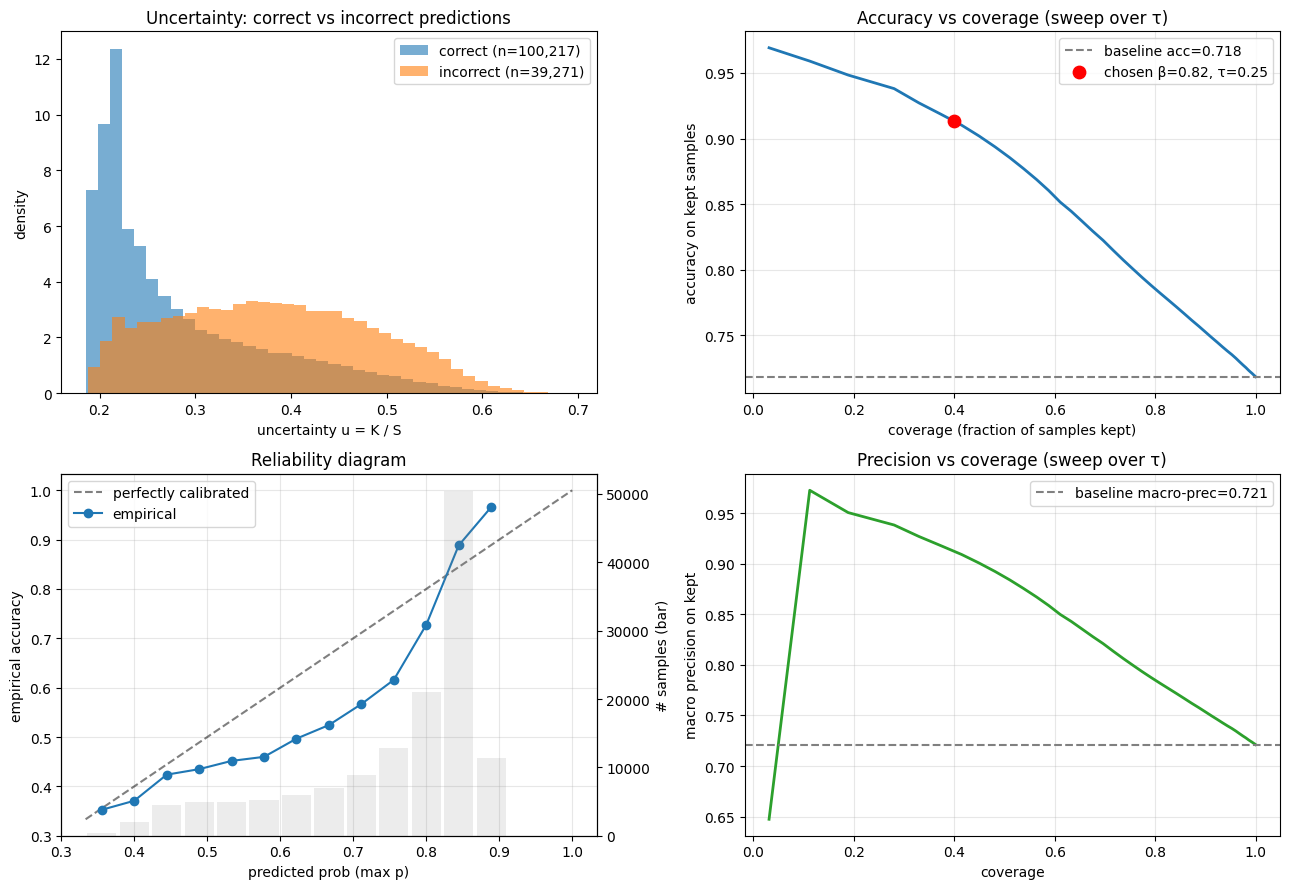

Saved plot: evidential_uncertainty.png


In [24]:
@torch.no_grad()
def collect_evidential_outputs(model, loader):
    model.eval()
    all_p, all_u, all_y = [], [], []
    for batch_idx, (inputs, targets) in enumerate(loader):
        if max_eval_batches is not None and batch_idx >= max_eval_batches:
            break
        inputs = inputs.to(device, dtype=torch.float32, non_blocking=pin_memory)
        with get_autocast_context():
            evidence = model(inputs)
        _, _, p, u = evidential_outputs(evidence.float())
        all_p.append(p.cpu().numpy())
        all_u.append(u.cpu().numpy())
        all_y.append(targets.numpy())
    return np.concatenate(all_p), np.concatenate(all_u), np.concatenate(all_y)


# Load best evidential checkpoint
ev_eval = deeplob_evidential(y_len=dataset_train.num_classes).to(device)
ev_eval.load_state_dict(torch.load(evidential_ckpt_path, map_location=device), strict=True)

p_test, u_test, y_test = collect_evidential_outputs(ev_eval, test_loader)
pred_test = p_test.argmax(axis=1)
maxp_test = p_test.max(axis=1)
correct = (pred_test == y_test)

print(f'Test samples: {len(y_test):,}')
print(f'Overall accuracy: {correct.mean():.4f}')
print(f'Uncertainty stats — mean={u_test.mean():.3f} median={np.median(u_test):.3f} '
      f'p10={np.quantile(u_test, 0.1):.3f} p90={np.quantile(u_test, 0.9):.3f}')
print(f'Uncertainty — correct preds: mean={u_test[correct].mean():.3f} | '
      f'incorrect preds: mean={u_test[~correct].mean():.3f}')


# --- Threshold sweep: pick best (beta, tau) on validation, report on test ---
p_val, u_val, y_val = collect_evidential_outputs(ev_eval, val_loader)
pred_val = p_val.argmax(axis=1); maxp_val = p_val.max(axis=1); correct_val = (pred_val == y_val)

def sweep_thresholds(maxp, u, correct, betas, taus):
    rows = []
    for b in betas:
        for t in taus:
            mask = (maxp > b) & (u < t)
            cov = mask.mean()
            if mask.sum() == 0:
                rows.append((b, t, cov, np.nan))
            else:
                rows.append((b, t, cov, correct[mask].mean()))
    return np.array(rows)

betas = np.linspace(0.34, 0.95, 25)
taus  = np.linspace(0.05, 1.00, 25)
val_sweep = sweep_thresholds(maxp_val, u_val, correct_val, betas, taus)

# Choose (beta, tau) that maximizes precision subject to coverage >= 10%
ok = (val_sweep[:, 2] >= 0.10)
if ok.any():
    best_idx = np.argmax(np.where(ok, val_sweep[:, 3], -np.inf))
else:
    best_idx = np.argmax(val_sweep[:, 3])
best_b, best_t, best_cov_val, best_acc_val = val_sweep[best_idx]
print(f'\nChosen on val: beta={best_b:.3f}, tau={best_t:.3f} -> coverage={best_cov_val:.3f}, acc_on_kept={best_acc_val:.4f}')

mask_test = (maxp_test > best_b) & (u_test < best_t)
print(f'Applied to test: coverage={mask_test.mean():.3f}, acc_on_kept={correct[mask_test].mean():.4f} '
      f'(baseline acc on all = {correct.mean():.4f})')

# Per-class precision on kept set
from sklearn.metrics import precision_score
prec_full = precision_score(y_test, pred_test, average=None, zero_division=0)
prec_kept = precision_score(y_test[mask_test], pred_test[mask_test], average=None, zero_division=0) \
    if mask_test.sum() else np.full(3, np.nan)
print(f'Precision per class — full: {np.round(prec_full, 4)} | kept: {np.round(prec_kept, 4)}')


# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Uncertainty histogram, correct vs incorrect
ax = axes[0, 0]
ax.hist(u_test[correct], bins=40, alpha=0.6, label=f'correct (n={correct.sum():,})', density=True)
ax.hist(u_test[~correct], bins=40, alpha=0.6, label=f'incorrect (n={(~correct).sum():,})', density=True)
ax.set_xlabel('uncertainty u = K / S')
ax.set_ylabel('density')
ax.set_title('Uncertainty: correct vs incorrect predictions')
ax.legend()

# (2) Accuracy vs coverage: sweep tau only at fixed beta=1/K (i.e. argmax)
ax = axes[0, 1]
tau_grid = np.linspace(0.05, 1.0, 100)
covs, accs = [], []
for t in tau_grid:
    m = u_test < t
    covs.append(m.mean())
    accs.append(correct[m].mean() if m.any() else np.nan)
ax.plot(covs, accs, lw=2)
ax.axhline(correct.mean(), color='gray', ls='--', label=f'baseline acc={correct.mean():.3f}')
ax.scatter([mask_test.mean()], [correct[mask_test].mean() if mask_test.any() else np.nan],
           c='red', s=80, zorder=5, label=f'chosen β={best_b:.2f}, τ={best_t:.2f}')
ax.set_xlabel('coverage (fraction of samples kept)')
ax.set_ylabel('accuracy on kept samples')
ax.set_title('Accuracy vs coverage (sweep over τ)')
ax.legend(); ax.grid(alpha=0.3)

# (3) Reliability: bin by max p, plot empirical accuracy in bin
ax = axes[1, 0]
edges = np.linspace(1.0 / 3, 1.0, 16)
centers = 0.5 * (edges[:-1] + edges[1:])
emp_acc = []; counts = []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (maxp_test >= lo) & (maxp_test < hi)
    emp_acc.append(correct[m].mean() if m.any() else np.nan)
    counts.append(m.sum())
emp_acc = np.array(emp_acc)
ax.plot([1/3, 1.0], [1/3, 1.0], 'k--', alpha=0.5, label='perfectly calibrated')
ax.plot(centers, emp_acc, 'o-', label='empirical')
ax2 = ax.twinx()
ax2.bar(centers, counts, width=(edges[1] - edges[0]) * 0.9, alpha=0.15, color='gray')
ax2.set_ylabel('# samples (bar)')
ax.set_xlabel('predicted prob (max p)')
ax.set_ylabel('empirical accuracy')
ax.set_title('Reliability diagram')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)

# (4) Precision-coverage tradeoff varying tau
ax = axes[1, 1]
prec_by_cov = []
for t in tau_grid:
    m = u_test < t
    if m.sum() < 10:
        prec_by_cov.append(np.nan)
    else:
        prec_by_cov.append(precision_score(y_test[m], pred_test[m], average='macro', zero_division=0))
ax.plot(covs, prec_by_cov, lw=2, color='C2')
base_prec = precision_score(y_test, pred_test, average='macro', zero_division=0)
ax.axhline(base_prec, color='gray', ls='--', label=f'baseline macro-prec={base_prec:.3f}')
ax.set_xlabel('coverage')
ax.set_ylabel('macro precision on kept')
ax.set_title('Precision vs coverage (sweep over τ)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('evidential_uncertainty.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved plot: evidential_uncertainty.png')


## Does it actually help?

Two questions to answer on the held-out test set. First, with no filtering applied, has swapping the head broken the baseline classifier? It shouldn't (we kept the backbone), but we have to check. Second, and more importantly, is the uncertainty signal *real*? To find out we bin the evidential predictions into ten equal-mass buckets by certainty `1 − u` and report accuracy in each. If `u` is meaningful, accuracy should climb monotonically from low-certainty to high-certainty buckets. If it doesn't, the whole construction is decoration.

Then we pick the trading-rule thresholds `(β, τ)` on the validation set, the highest validation accuracy subject to keeping at least 10% coverage, and apply that rule to the test set. Three numbers go side by side: the original softmax, the evidential model with no filter, and the evidential model with `(β, τ)` applied.

model                                       cov         n    acc   prec    rec     f1
Softmax (baseline)                       100.0%   139,488 0.7216 0.7224 0.7209 0.7213
Evidential (all)                         100.0%   139,488 0.7185 0.7212 0.7189 0.7187
Evidential (β=0.82, τ=0.25)               40.0%    55,764 0.9137 0.9130 0.9126 0.9127

Per-class precision:
  Softmax (baseline)                       [0.6892 0.7857 0.6923]
  Evidential (all)                         [0.7107 0.7977 0.6551]
  Evidential (β=0.82, τ=0.25)              [0.9146 0.9279 0.8964]

=== Test metrics by certainty decile (1 - u, low → high) ===
bin cert range                    n    acc   prec    rec     f1
  0 [0.306, 0.528]           13,949 0.4118 0.4265 0.4146 0.4070
  1 [0.528, 0.591]           13,949 0.4896 0.5037 0.4846 0.4850
  2 [0.591, 0.641]           13,949 0.5365 0.5445 0.5319 0.5343
  3 [0.641, 0.686]           13,948 0.6118 0.6165 0.6116 0.6122
  4 [0.686, 0.723]           13,949 0.6943 0.6950 0.69

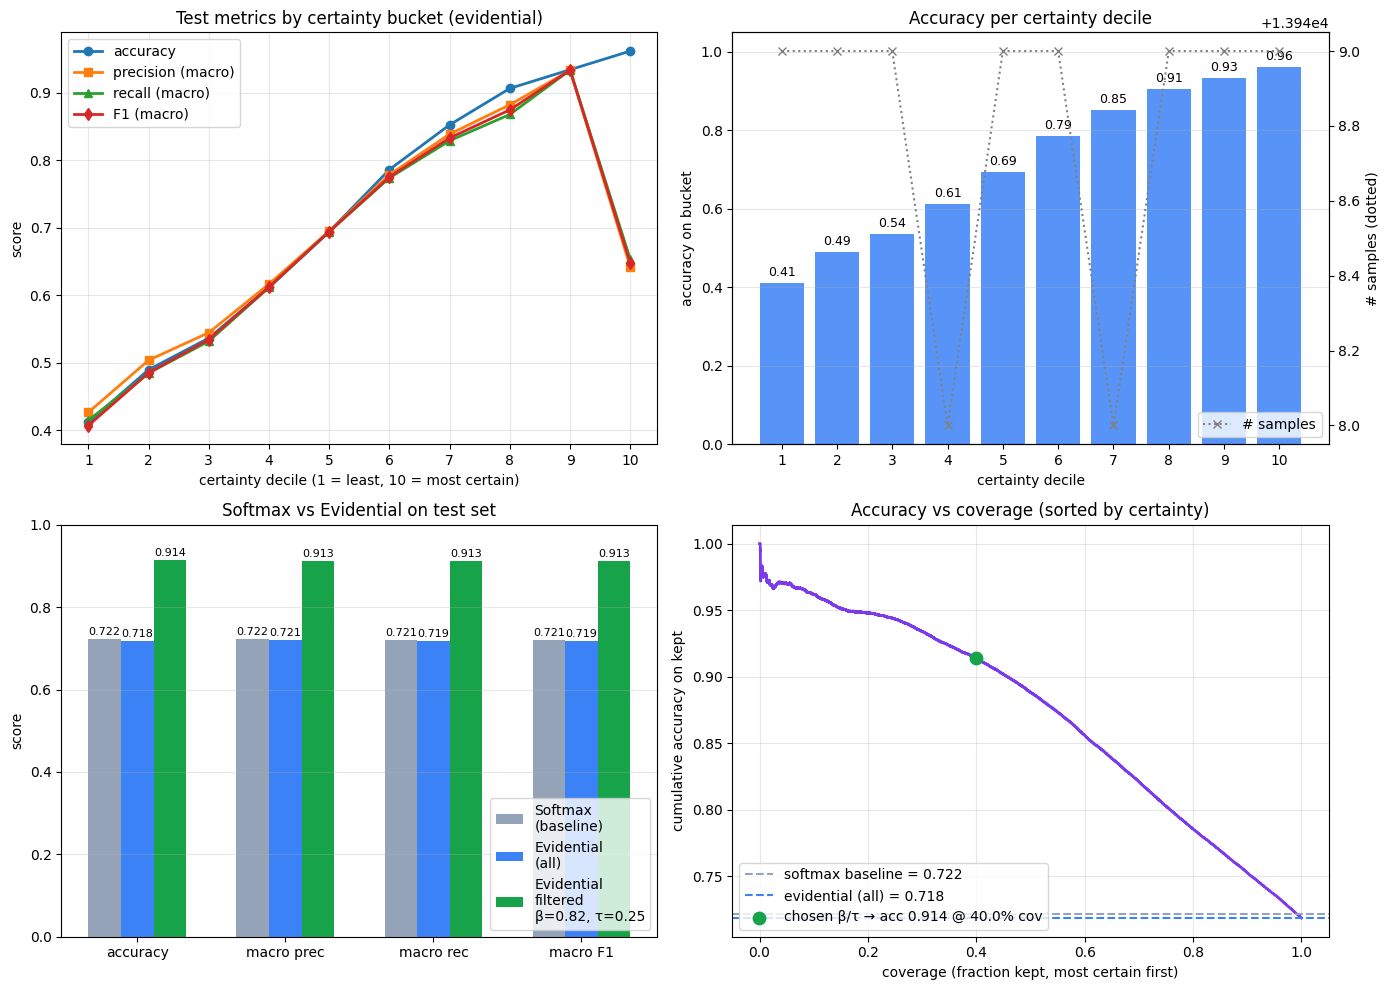


Saved: evidential_vs_softmax.png


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# --- Load both models and predict on test set ---
@torch.no_grad()
def predict_softmax_probs(model, loader):
    model.eval()
    ps, ys = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        with get_autocast_context():
            p = model(xb)
        ps.append(p.float().cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ps), np.concatenate(ys)


m_soft = deeplob(y_len=dataset_train.num_classes).to(device)
m_soft.load_state_dict(torch.load(best_model_path, map_location=device), strict=True)
p_soft, y_soft = predict_softmax_probs(m_soft, test_loader)
pred_soft = p_soft.argmax(1)

m_ev = deeplob_evidential(y_len=dataset_train.num_classes).to(device)
m_ev.load_state_dict(torch.load(evidential_ckpt_path, map_location=device), strict=True)
p_ev, u_ev, y_ev = collect_evidential_outputs(m_ev, test_loader)
pred_ev = p_ev.argmax(1); maxp_ev = p_ev.max(1)
assert (y_soft == y_ev).all(), 'test labels diverged between runs'
y_t = y_ev

# Reuse (best_b, best_t) picked on val in the previous cell
mask_test = (maxp_ev > best_b) & (u_ev < best_t)

def metrics(y_true, y_pred):
    return dict(
        n=len(y_true),
        acc=accuracy_score(y_true, y_pred),
        prec=precision_score(y_true, y_pred, average='macro', zero_division=0),
        rec=recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1=f1_score(y_true, y_pred, average='macro', zero_division=0),
        prec_per_class=precision_score(y_true, y_pred, average=None, zero_division=0),
    )

rows = [
    ('Softmax (baseline)',           metrics(y_t, pred_soft),                       1.0),
    ('Evidential (all)',             metrics(y_t, pred_ev),                          1.0),
    (f'Evidential (β={best_b:.2f}, τ={best_t:.2f})',
     metrics(y_t[mask_test], pred_ev[mask_test]),                                   mask_test.mean()),
]
print(f'{"model":<40s} {"cov":>6s} {"n":>9s} {"acc":>6s} {"prec":>6s} {"rec":>6s} {"f1":>6s}')
for name, r, cov in rows:
    print(f'{name:<40s} {cov*100:5.1f}% {r["n"]:>9,d} '
          f'{r["acc"]:.4f} {r["prec"]:.4f} {r["rec"]:.4f} {r["f1"]:.4f}')
print()
print('Per-class precision:')
for name, r, _ in rows:
    print(f'  {name:<40s} {np.round(r["prec_per_class"], 4)}')


# --- Certainty-decile analysis ---
certainty = 1.0 - u_ev
edges = np.quantile(certainty, np.linspace(0, 1, 11))
edges[0] -= 1e-9; edges[-1] += 1e-9
bins = np.clip(np.digitize(certainty, edges, right=False) - 1, 0, 9)

per_bin = []
for b in range(10):
    sel = (bins == b)
    per_bin.append(dict(
        lo=edges[b], hi=edges[b + 1], n=int(sel.sum()),
        acc=accuracy_score(y_t[sel], pred_ev[sel]),
        prec=precision_score(y_t[sel], pred_ev[sel], average='macro', zero_division=0),
        rec=recall_score(y_t[sel], pred_ev[sel], average='macro', zero_division=0),
        f1=f1_score(y_t[sel], pred_ev[sel], average='macro', zero_division=0),
    ))

print('\n=== Test metrics by certainty decile (1 - u, low → high) ===')
print(f'{"bin":>3s} {"cert range":<22s} {"n":>8s} {"acc":>6s} {"prec":>6s} {"rec":>6s} {"f1":>6s}')
for i, r in enumerate(per_bin):
    rng = f'[{r["lo"]:.3f}, {r["hi"]:.3f}]'
    print(f'{i:>3d} {rng:<22s} {r["n"]:>8,d} {r["acc"]:.4f} {r["prec"]:.4f} {r["rec"]:.4f} {r["f1"]:.4f}')


# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
xs = np.arange(10)
ax.plot(xs, [r['acc']  for r in per_bin], 'o-', label='accuracy',         lw=2)
ax.plot(xs, [r['prec'] for r in per_bin], 's-', label='precision (macro)', lw=2)
ax.plot(xs, [r['rec']  for r in per_bin], '^-', label='recall (macro)',    lw=2)
ax.plot(xs, [r['f1']   for r in per_bin], 'd-', label='F1 (macro)',        lw=2)
ax.set_xticks(xs); ax.set_xticklabels([str(i + 1) for i in xs])
ax.set_xlabel('certainty decile (1 = least, 10 = most certain)')
ax.set_ylabel('score'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Test metrics by certainty bucket (evidential)')

ax = axes[0, 1]
ax.bar(xs, [r['acc'] for r in per_bin], color='#3b82f6', alpha=0.85)
for i, r in enumerate(per_bin):
    ax.text(i, r['acc'] + 0.01, f'{r["acc"]:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels([str(i + 1) for i in xs])
ax.set_xlabel('certainty decile'); ax.set_ylabel('accuracy on bucket')
ax.set_title('Accuracy per certainty decile')
ax.set_ylim(0, 1.05); ax.grid(alpha=0.3, axis='y')
ax2 = ax.twinx()
ax2.plot(xs, [r['n'] for r in per_bin], color='gray', ls=':', marker='x', label='# samples')
ax2.set_ylabel('# samples (dotted)'); ax2.legend(loc='lower right')

ax = axes[1, 0]
metric_names = ['acc', 'prec', 'rec', 'f1']
labels_pretty = ['Softmax\n(baseline)', 'Evidential\n(all)',
                 f'Evidential\nfiltered\nβ={best_b:.2f}, τ={best_t:.2f}']
width = 0.22; xpos = np.arange(len(metric_names))
colors = ['#94a3b8', '#3b82f6', '#16a34a']
for i, (name, r, _) in enumerate(rows):
    vals = [r['acc'], r['prec'], r['rec'], r['f1']]
    ax.bar(xpos + (i - 1) * width, vals, width, label=labels_pretty[i], color=colors[i])
    for j, v in enumerate(vals):
        ax.text(xpos[j] + (i - 1) * width, v + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(['accuracy', 'macro prec', 'macro rec', 'macro F1'])
ax.set_ylim(0, 1.0); ax.set_ylabel('score')
ax.set_title('Softmax vs Evidential on test set')
ax.grid(alpha=0.3, axis='y'); ax.legend(loc='lower right')

ax = axes[1, 1]
order = np.argsort(-certainty)
cum_correct = np.cumsum((pred_ev[order] == y_t[order]).astype(float))
n_seq = np.arange(1, len(y_t) + 1)
ax.plot(n_seq / len(y_t), cum_correct / n_seq, lw=2, color='#7c3aed')
ax.axhline(rows[0][1]['acc'], ls='--', color='#94a3b8', label=f'softmax baseline = {rows[0][1]["acc"]:.3f}')
ax.axhline(rows[1][1]['acc'], ls='--', color='#3b82f6', label=f'evidential (all) = {rows[1][1]["acc"]:.3f}')
ax.scatter([mask_test.mean()], [rows[2][1]['acc']], c='#16a34a', s=80, zorder=5,
           label=f'chosen β/τ → acc {rows[2][1]["acc"]:.3f} @ {mask_test.mean()*100:.1f}% cov')
ax.set_xlabel('coverage (fraction kept, most certain first)')
ax.set_ylabel('cumulative accuracy on kept')
ax.set_title('Accuracy vs coverage (sorted by certainty)')
ax.grid(alpha=0.3); ax.legend(loc='lower left')

plt.tight_layout()
fig.savefig('evidential_vs_softmax.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nSaved: evidential_vs_softmax.png')
